In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('synthetic_dataset.csv')

In [3]:
df.head()

,index,X,Y,class
0,0,1.4609,-0.6585,0.0
1,1,-1.4656,0.0195,1.0
2,2,2.7821,0.1959,1.0
3,3,-1.6451,-0.1581,1.0
4,4,1.8088,-0.4874,0.0


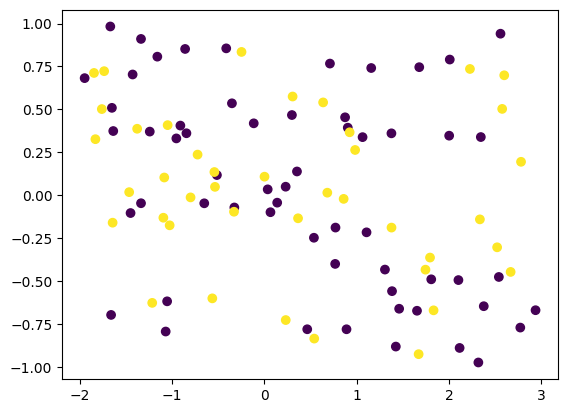

In [4]:
plt.scatter(df['X'],df['Y'],c=df['class'])

In [5]:
X = df.iloc[:,0:2].values
y = df.iloc[:,-1].values

In [6]:
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense

In [17]:
model = Sequential()

model.add(Dense(2,activation='relu',input_dim=2))
model.add(Dense(1,activation='relu'))

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                      │ (None, 2)                   │               6 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │               3 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 9 (36.00 B)

 Trainable params: 9 (36.00 B)

 Non-trainable params: 0 (0.00 B)

In [18]:
# Set parameters to 0
model.get_weights()

[array([[-0.28624398,  0.03785074],
        [-0.12032402,  0.16219604]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[-0.7459415 ],
        [ 0.12535453]], dtype=float32),
 array([0.], dtype=float32)]

In [19]:
initial_weights = model.get_weights()

In [20]:
initial_weights[0] = np.ones(model.get_weights()[0].shape)*0.5
initial_weights[1] = np.ones(model.get_weights()[1].shape)*0.5
initial_weights[2] = np.ones(model.get_weights()[2].shape)*0.5
initial_weights[3] = np.ones(model.get_weights()[3].shape)*0.5

In [21]:
model.set_weights(initial_weights)

In [22]:
model.get_weights()

[array([[0.5, 0.5],
        [0.5, 0.5]], dtype=float32),
 array([0.5, 0.5], dtype=float32),
 array([[0.5],
        [0.5]], dtype=float32),
 array([0.5], dtype=float32)]

In [23]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [24]:
history = model.fit(X,y,epochs=100,validation_split=0.2)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 102ms/step - accuracy: 0.4000 - loss: 9.5687 - val_accuracy: 0.4500 - val_loss: 8.7683
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.4000 - loss: 9.5686 - val_accuracy: 0.4500 - val_loss: 8.7683
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.4000 - loss: 9.5684 - val_accuracy: 0.4500 - val_loss: 8.7683
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.4000 - loss: 9.5683 - val_accuracy: 0.4500 - val_loss: 8.7683
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.4000 - loss: 9.5682 - val_accuracy: 0.4500 - val_loss: 8.7683
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.4000 - loss: 9.5680 - val_accuracy: 0.4500 - val_loss: 8.7683
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.4000 - loss: 9.5679 - val_accuracy: 0.4500 - val_loss: 8.7683
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.4000 - loss: 9.5678 - val_accuracy: 0.4500 - val_loss

In [25]:
model.get_weights()

[array([[0.54922414, 0.54922414],
        [0.45077527, 0.45077527]], dtype=float32),
 array([0.54922414, 0.54922414], dtype=float32),
 array([[0.5522268],
        [0.5522268]], dtype=float32),
 array([0.5484838], dtype=float32)]

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 7s 766us/step


<Axes: >

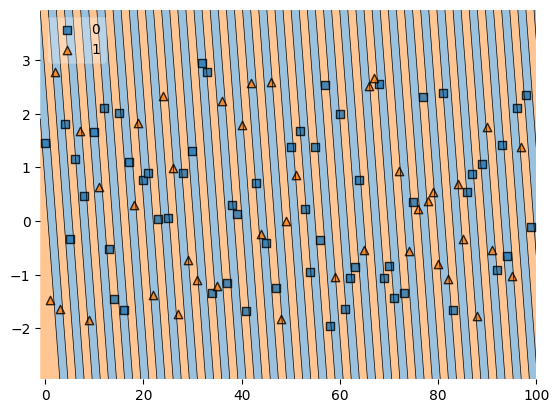

In [26]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X,y.astype('int'), clf=model, legend=2)